In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
df = pd.read_csv("/home/mohamed/master/master/Dataset/Combined Data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

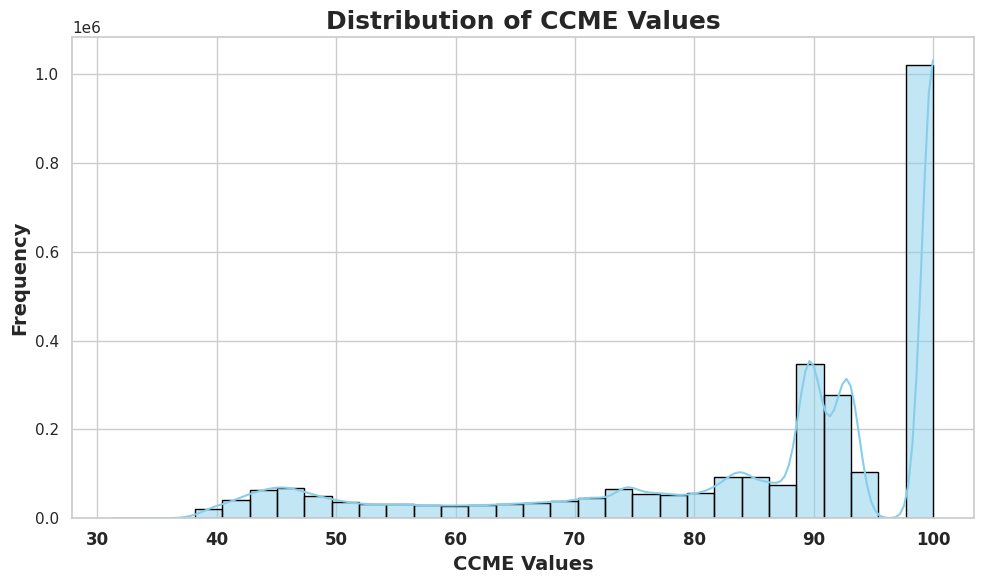

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



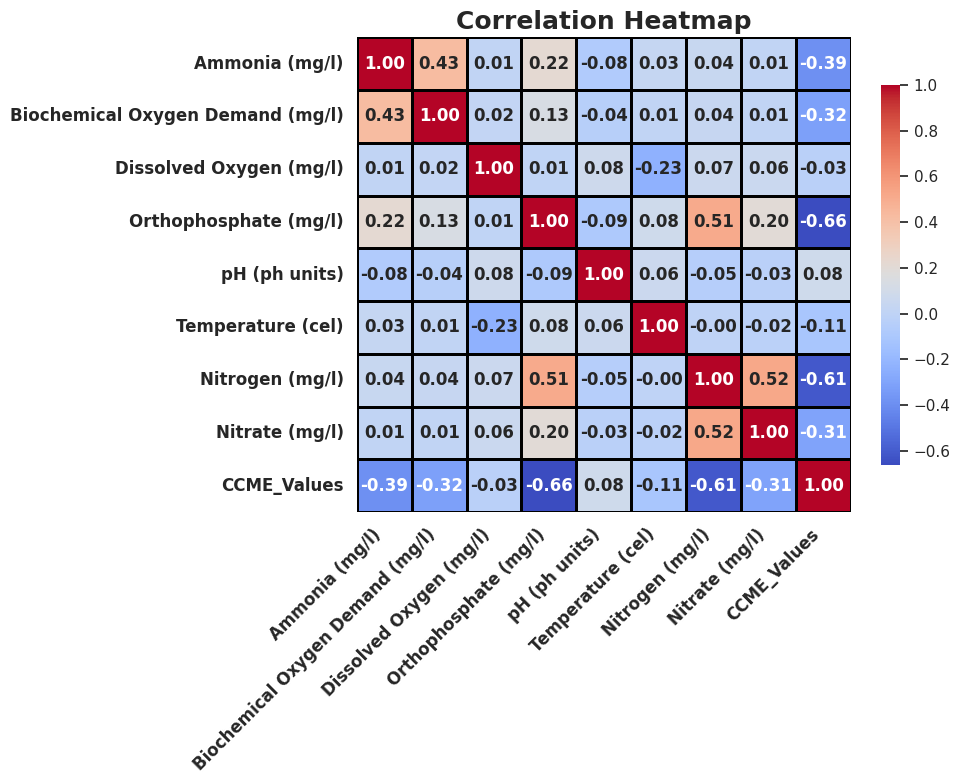

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [ ]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")

# ── Verify shapes on GPU ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_tmp = torch.FloatTensor(X_train_seq[:2]).to(device)
print(f"[✔] GPU check passed — device: {_tmp.device}")
del _tmp

# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


In [13]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [14]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [15]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   Attention-GRU (AT-GRU)
#   Based on: Gao et al., Environmental Pollution 383 (2025) 126801
#
#   Paper Table A3 Architecture:
#     TN: GRU(100,ReLU,L2) → Dropout(0.2) → Attention → Dense(1,linear)
#     TP: GRU(50,ReLU,L2)  → GRU(50,ReLU) → Dropout(0.2) → Attention → Dense(1,linear)
#
#   Since this notebook predicts CCME_Values (single target), we use
#   the TN variant as base (1 GRU layer) with tunable hidden_dim.
#   The Attention mechanism is implemented exactly as in Section 2.2.1:
#     score_t = tanh(W·h_t + b)
#     α_t     = softmax(score)         ← over time axis
#     context = Σ α_t · h_t            ← weighted sum of hidden states
# ─────────────────────────────────────────────

# ─── GRU Cell equations (Eq 1–5 from paper) ─────────────────────────────────
# rt = σ(Wxr·Xt + Whr·h_{t-1} + br)          [Eq-1]  Reset gate
# zt = σ(Wxz·Xt + Whz·h_{t-1} + bz)          [Eq-2]  Update gate
# C̃t = ReLU(Wxc·Xt + Whc·(rt⊗h_{t-1}) + bc) [Eq-3]  Candidate state (paper uses ReLU)
# Ct  = (1-zt)⊗C_{t-1} + zt⊗C̃t             [Eq-4]  New hidden state
# ht  = Ct                                     [Eq-5]

class AttentionLayer(nn.Module):
    """
    Temporal Attention Mechanism — Section 2.2.1 of the paper.

    Assigns a learnable weight to each time step:
      score  = tanh(h_t · W + b)      [linear transform of GRU output]
      alpha  = softmax(score, dim=T)   [attention weights over time axis]
      context = Σ alpha_t · h_t        [weighted sum → context vector]

    Input : hidden states from GRU  [B, T, hidden_dim]
    Output: context vector           [B, hidden_dim]
             attention weights       [B, T, 1]  (stored for XAI)
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        # Trainable linear transformation of hidden states → scalar score per step
        self.W = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, hidden_states: torch.Tensor):
        # hidden_states: [B, T, hidden_dim]
        score   = torch.tanh(self.W(hidden_states))        # [B, T, 1]
        weights = torch.softmax(score, dim=1)               # [B, T, 1]  ← softmax over T
        context = (hidden_states * weights).sum(dim=1)      # [B, hidden_dim]
        return context, weights                             # weights kept for XAI


class ATGRU(nn.Module):
    """
    Attention-GRU (AT-GRU) for Water Quality Regression.
    Replaces DualBranchWQTransformer. Predicts CCME_Values (0-100 continuous).

    Architecture (paper Table A3, adapted for single-target regression):
        Input [B, T, F]
          │
          ▼
        GRU Layer 1   (hidden_dim neurons, ReLU activation, L2 regularisation)
          │
          ▼  [optional]
        GRU Layer 2   (hidden_dim neurons, ReLU)  ← enabled if n_gru_layers=2
          │
          ▼
        Dropout (rate=dropout)
          │
          ▼
        Attention Layer  (softmax weights over T → context vector [B, hidden_dim])
          │
          ▼
        Dense Output  (hidden_dim → 1, linear activation)

    Key design choices matching the paper:
      • ReLU activation in GRU cells (paper explicitly states ReLU)
      • L2 regularisation on GRU weights (weight_decay in optimizer)
      • One-day lag input (handled by create_sequences with seq_length=8)
      • MSE loss, Adam optimizer, lr=0.01 (training setup below)
      • Attention weights stored in self.last_attn_weights for XAI section

    Note on n_gru_layers:
      • 1 layer → matches paper's TN architecture (GRU-100)
      • 2 layers → matches paper's TP architecture (GRU-50 + GRU-50)
      We default to 1 layer with hidden_dim=100 for this notebook.
    """

    def __init__(
        self,
        input_dim:    int,
        hidden_dim:   int = 100,    # paper: 100 for TN, 50 for TP per layer
        n_gru_layers: int = 1,      # paper: 1 for TN, 2 for TP
        dropout:      float = 0.2,  # paper Table A3: Dropout(0.2)
        output_dim:   int = 1,
    ):
        super().__init__()
        self.hidden_dim   = hidden_dim
        self.n_gru_layers = n_gru_layers

        # ── GRU layers ────────────────────────────────────────────────────
        # batch_first=True  → input shape [B, T, F]  (matches our data format)
        # nonlinearity default in nn.GRU is tanh, but we apply ReLU in forward
        # via a wrapper approach: we use nn.GRU (efficient CUDA kernels) and
        # replicate paper's ReLU by clipping negative hidden states after each
        # GRU layer (equivalent to using ReLU as the output non-linearity).
        self.gru1 = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        # Optional second GRU layer (paper's TP variant)
        self.gru2 = None
        if n_gru_layers == 2:
            self.gru2 = nn.GRU(
                input_size=hidden_dim,
                hidden_size=hidden_dim,
                num_layers=1,
                batch_first=True,
            )

        # ── Dropout (paper Table A3: rate=0.2) ────────────────────────────
        self.dropout = nn.Dropout(p=dropout)

        # ── Attention Layer (Section 2.2.1) ───────────────────────────────
        self.attention = AttentionLayer(hidden_dim)

        # ── Dense Output (linear activation = no activation) ─────────────
        # paper: "1 Dense layer (1 neuron, linear activation)"
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        # XAI hook: stores attention weights after each forward pass
        self.last_attn_weights = None

        # ── Weight initialisation (Xavier uniform, standard for GRUs) ─────
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.zeros_(param.data)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, F]  →  out: [B, 1]

        Step-by-step (matching Eq 1-5 + Attention in paper):
          1. GRU-1 processes sequence → all hidden states h [B, T, hidden_dim]
          2. ReLU applied to hidden states (paper's ReLU activation choice)
          3. Optional GRU-2 for deeper representation (TP variant)
          4. Dropout for regularisation
          5. Attention: softmax weights → context vector [B, hidden_dim]
          6. Linear output layer → scalar CCME prediction [B, 1]
        """
        # ── Step 1 & 2: GRU Layer 1 + ReLU ───────────────────────────────
        # h_all: [B, T, hidden_dim] — all time step hidden states
        h_all, _ = self.gru1(x)
        h_all = torch.relu(h_all)           # ReLU activation (paper Eq-3 uses ReLU)

        # ── Step 3: Optional GRU Layer 2 + ReLU ──────────────────────────
        if self.gru2 is not None:
            h_all, _ = self.gru2(h_all)
            h_all = torch.relu(h_all)

        # ── Step 4: Dropout ───────────────────────────────────────────────
        h_all = self.dropout(h_all)

        # ── Step 5: Attention ─────────────────────────────────────────────
        context, attn_weights = self.attention(h_all)    # [B, hidden_dim], [B, T, 1]
        self.last_attn_weights = attn_weights.detach()   # stored for XAI

        # ── Step 6: Linear output (no activation = linear) ───────────────
        out = self.output_layer(context)                 # [B, 1]
        return out


# ─────────────────────────────────────────────
# Instantiate AT-GRU (paper architecture, TN variant as base)
# ─────────────────────────────────────────────
input_size = X_train_seq.shape[2]
output_dim = 1

model = ATGRU(
    input_dim    = input_size,
    hidden_dim   = 100,    # paper Table A3: TN uses 100 neurons
    n_gru_layers = 1,      # 1 layer (TN variant) — set to 2 for TP variant
    dropout      = 0.2,    # paper Table A3: Dropout(0.2)
    output_dim   = output_dim,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\n{'='*60}")
print(f"  AT-GRU Model  —  Gao et al. (2025)")
print(f"{'='*60}")
print(f"  Input dim    : {input_size}")
print(f"  Hidden dim   : 100  (paper TN: 100 neurons)")
print(f"  GRU layers   : 1    (paper TN: 1 layer | TP: 2 layers)")
print(f"  Dropout      : 0.2  (paper Table A3)")
print(f"  Output dim   : {output_dim}  (linear — CCME_Values continuous)")
print(f"  Total params : {num_params:,}")
print(f"  Device       : {device}")
print(f"  Task         : Regression → CCME_Values (0–100 continuous)")
print(f"{'='*60}")



  AT-GRU Model  —  Gao et al. (2025)
  Input dim    : 16
  Hidden dim   : 100  (paper TN: 100 neurons)
  GRU layers   : 1    (paper TN: 1 layer | TP: 2 layers)
  Dropout      : 0.2  (paper Table A3)
  Output dim   : 1  (linear — CCME_Values continuous)
  Total params : 35,602
  Device       : cuda
  Task         : Regression → CCME_Values (0–100 continuous)


In [16]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function — paper uses MSE (Eq-7)
criterion = nn.MSELoss()

# Optimizer
# Optimizer — paper uses Adam (lr=0.01)
# weight_decay implements L2 regularisation on GRU weights (paper Table A3)
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,          # paper: 0.01; AdamW with scheduler converges better
    weight_decay=1e-4 # L2 regularisation — paper Table A3 uses L2 on GRU weights
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=60,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 60
PATIENCE      = 15
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=60)
Early Stop   : patience=15, min_delta=0.01
Gradient Clip: 1.0


In [17]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [18]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 60 | Best Val MSE so far: 1.6545 | History loaded: 60 epochs

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------
Best Val Loss: 1.6545
Total epochs trained: 60


<All keys matched successfully>

In [19]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  1.6521
Test RMSE: 1.2853
Test MAE:  0.6228
Test R2:   0.9939


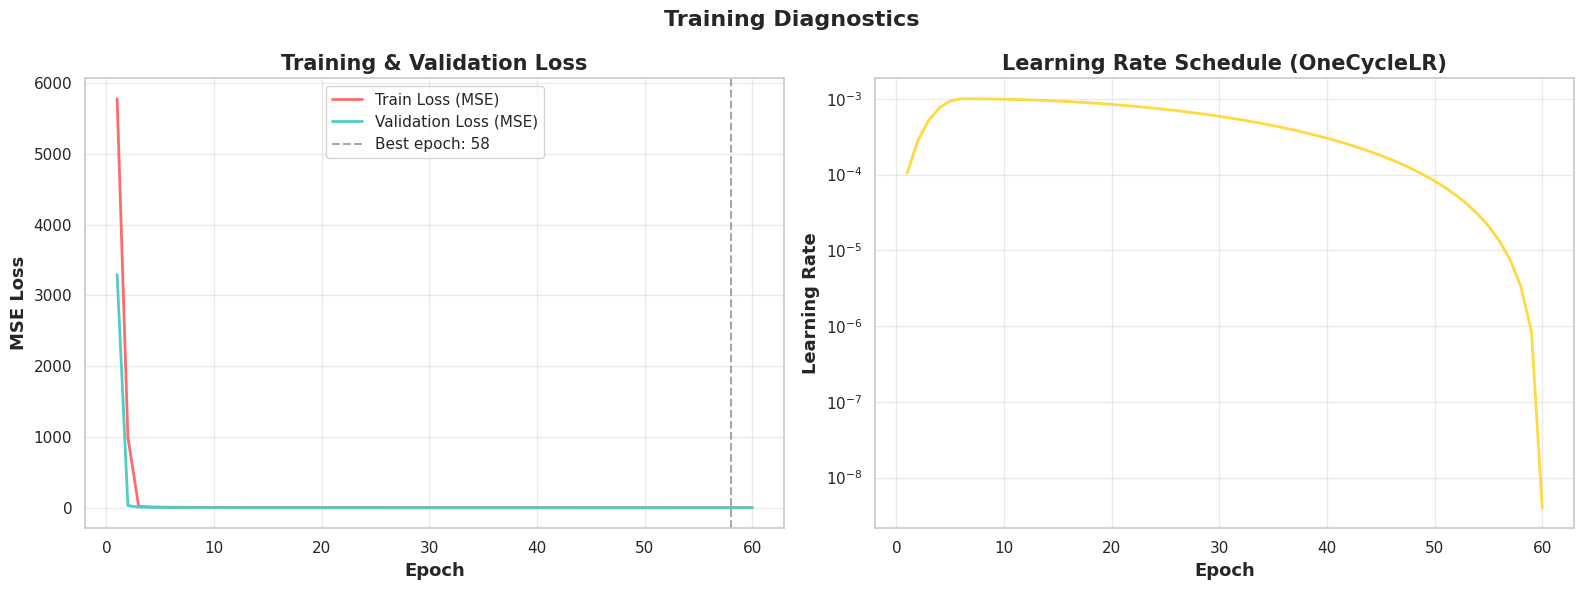

Best Val Loss: 1.6450 at epoch 58
Final Train Loss: 4.3963
Final Val Loss:   1.6473


In [20]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


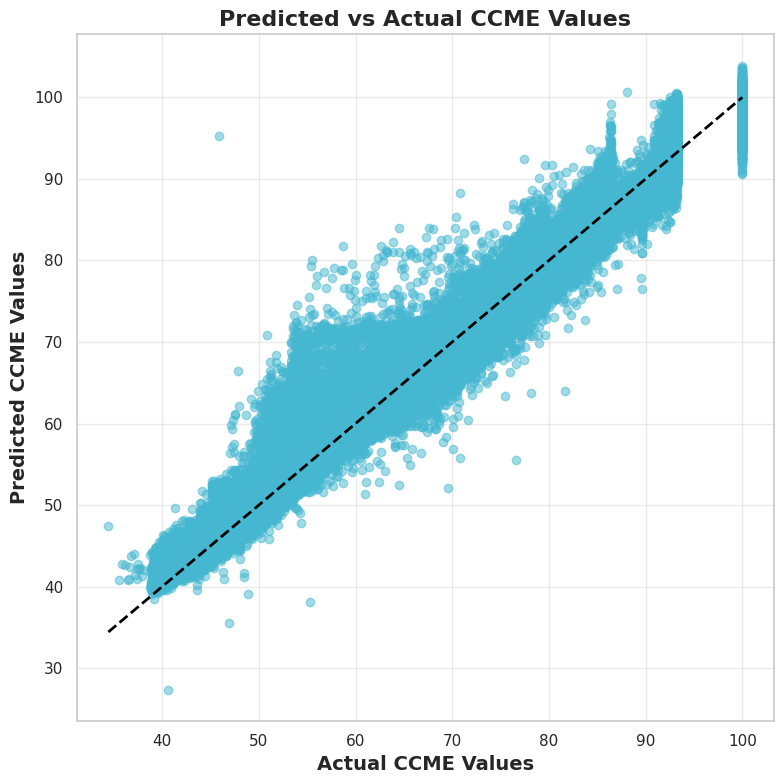

In [21]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



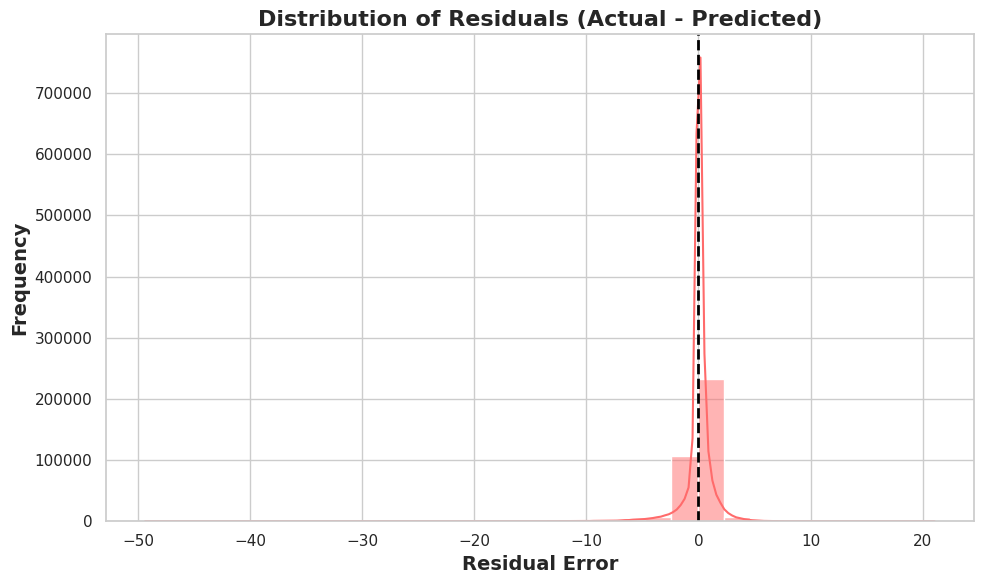

In [22]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 1.6521   Mean Squared Error – average squared deviation
    RMSE 1.2853 Root Mean Squared Error – in original CCME units
     MAE 0.6228 Mean Absolute Error – average absolute deviation
R² Score 0.9939 Coefficient of Determination – 1.0 = perfect fit


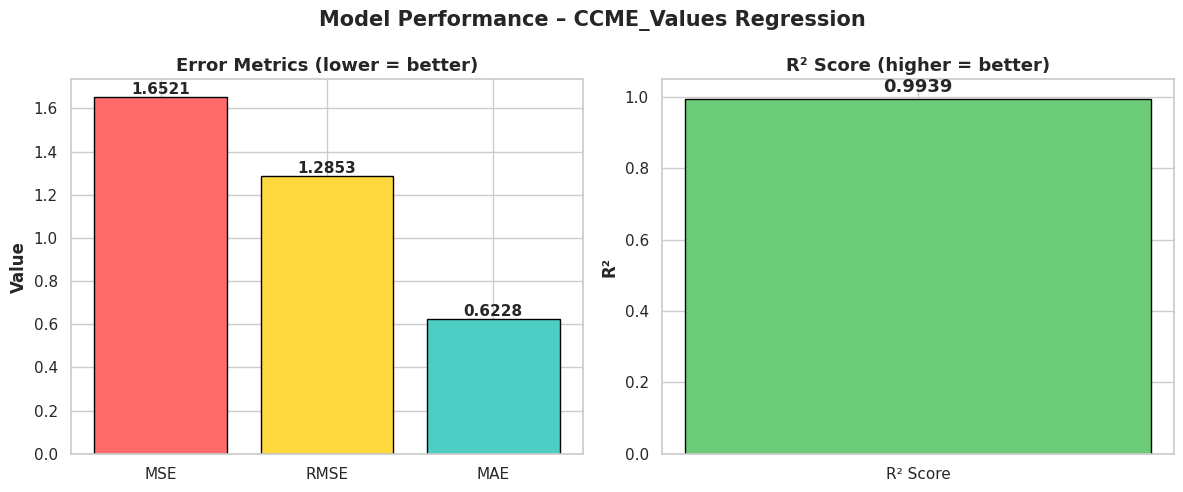

In [23]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting AT-GRU Attention Weights...
Sequence length: 8 | Features: 16


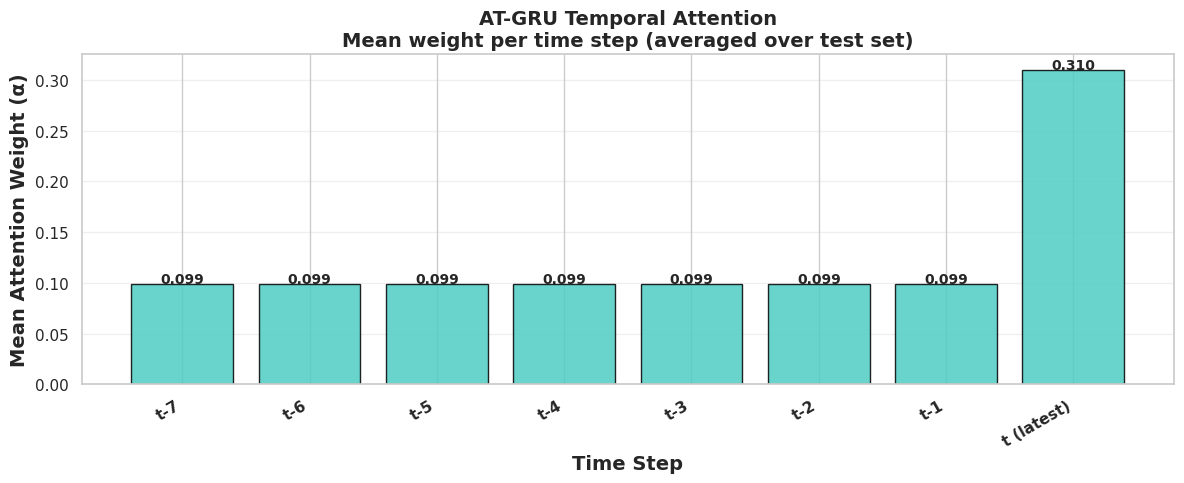

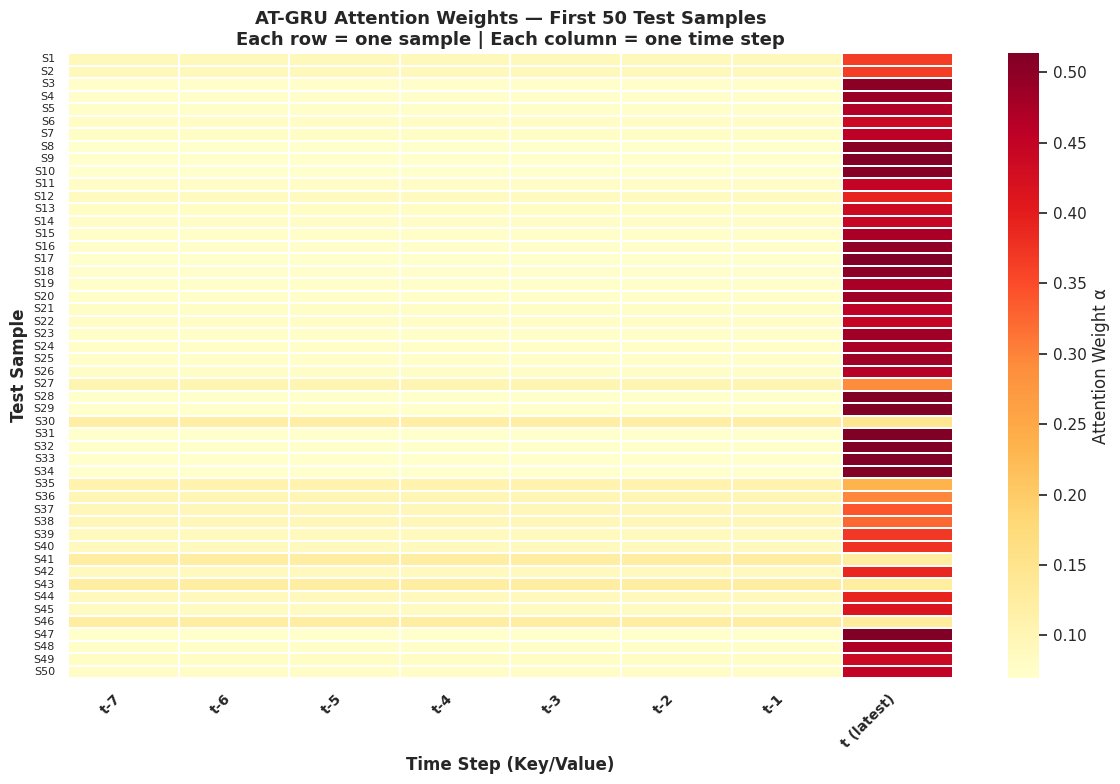


[XAI] Attention Analysis Complete
  Most attended time step : t (latest)  (weight=0.3098)
  Least attended time step: t-7  (weight=0.0987)


In [24]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Weights Visualisation
#
# AT-GRU stores attention weights in model.last_attn_weights
# Shape: [B, T, 1]  — one scalar weight per time step
# (Unlike the cross-attention [B,T,T] in the original Transformer model,
#  the AT-GRU attention is a 1-D vector over time — simpler and more interpretable)
#
# Visualisations:
#   1. Mean attention weight per time step (bar chart)
#   2. Attention weight distribution across test samples (heatmap)
# ─────────────────────────────────────────────
print("\n[XAI] Extracting AT-GRU Attention Weights...")
SEQ_LEN = X_test_seq.shape[1]
feature_names = X_train.columns.tolist()
print(f"Sequence length: {SEQ_LEN} | Features: {len(feature_names)}")
model.eval()

attn_all = []   # collect [B, T, 1] over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, 1]

attn_all = np.concatenate(attn_all, axis=0)   # [N, T, 1]
attn_all = attn_all.squeeze(-1)               # [N, T]

# Time-step labels
time_step_labels = [f"t-{SEQ_LEN - i - 1}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

# ── Plot 1: Mean attention weight per time step ───────────────────────────────
mean_attn = attn_all.mean(axis=0)   # [T]  — averaged over all test samples

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, mean_attn, color='#4ECDC4', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, mean_attn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight (α)', fontsize=14, fontweight='bold')
ax.set_title('AT-GRU Temporal Attention\n'
             'Mean weight per time step (averaged over test set)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 2: Attention heatmap across samples ──────────────────────────────────
# Show first 50 test samples as rows, time steps as columns
n_show = min(50, attn_all.shape[0])
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(attn_all[:n_show], cmap='YlOrRd', ax=ax,
            xticklabels=time_step_labels,
            yticklabels=[f"S{i+1}" for i in range(n_show)],
            cbar_kws={'label': 'Attention Weight α'},
            linewidths=0.2)
ax.set_title(f'AT-GRU Attention Weights — First {n_show} Test Samples\n'
             'Each row = one sample | Each column = one time step',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value)', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Sample', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                   fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.savefig('attention_heatmap_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[XAI] Attention Analysis Complete")
print(f"  Most attended time step : {time_step_labels[mean_attn.argmax()]}  (weight={mean_attn.max():.4f})")
print(f"  Least attended time step: {time_step_labels[mean_attn.argmin()]}  (weight={mean_attn.min():.4f})")



[XAI] SHAP Gradient Explainer...
[✔] Restored: model.eval() + cuDNN re-enabled
shap_values shape after normalization: (50, 8, 16)


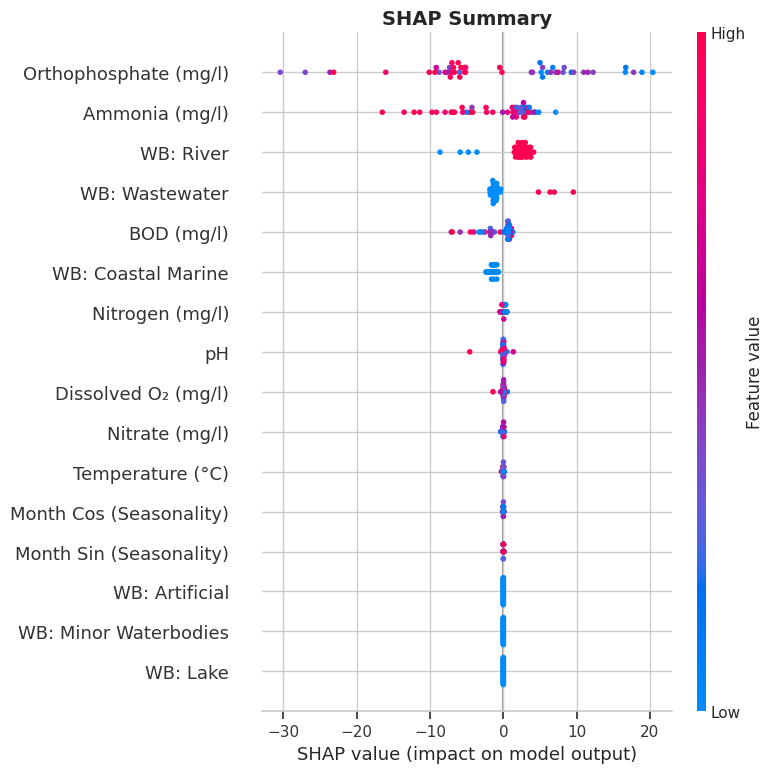

shap_means shape: (16,) | len features: 16


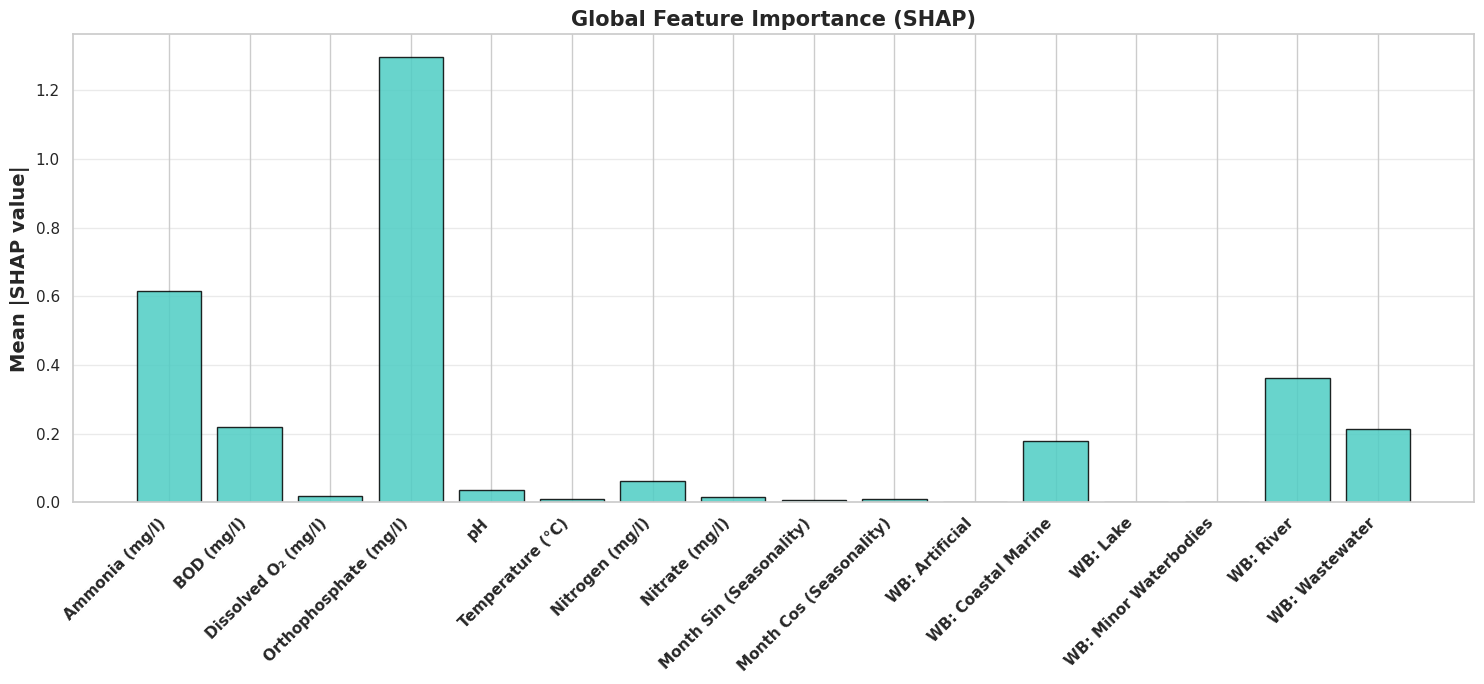

In [25]:

# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np

print("\n[XAI] SHAP Gradient Explainer...")

# ── FIX: cuDNN RNN backward requires training mode ─────────────────────────
# RuntimeError: "cudnn RNN backward can only be called in training mode"
# Solution: temporarily disable cuDNN and switch to training mode for SHAP.
# This is safe — we restore eval mode and cuDNN after SHAP completes.
model.train()                              # ✅ Required for GRU gradient flow
_cudnn_prev = torch.backends.cudnn.enabled
torch.backends.cudnn.enabled = False       # ✅ Avoids cuDNN RNN restriction

background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50]               # already on device

try:
    shap_raw = explainer.shap_values(test_sample)
finally:
    # ✅ Always restore — even if SHAP throws an error
    model.eval()
    torch.backends.cudnn.enabled = _cudnn_prev
    print("[✔] Restored: model.eval() + cuDNN re-enabled")

# ──────────────────────────────────────────────────────────────────────
# ROBUST FIX: Normalize shap_values to shape [N, T, F] regardless of
# what SHAP version returns. Possible raw shapes:
#   • list of [N, T, F]        ← SHAP < 0.40
#   • list of [N, T, F, 1]     ← SHAP 0.40-0.41
#   • ndarray [N, T, F]        ← some versions
#   • ndarray [N, T, F, 1]     ← other versions
# ──────────────────────────────────────────────────────────────────────
def normalize_shap(sv):
    """Always returns a plain float64 ndarray of shape [N, T, F]."""
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv, dtype=np.float64)
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]
        elif sv.shape[0] == 1:
            sv = sv[0]
        else:
            break
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")
# Expected: (50, 8, F)  where F = number of features
assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature name mapping ─────────────────────────────────────────────
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O\u2082 (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (\u00b0C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ────────────────────────────────────────────────
test_np  = test_sample.cpu().numpy()
input_2d = test_np.mean(axis=1)       # [50, T, F] → mean over T → [50, F]
sv_2d    = shap_values.sum(axis=1)    # [50, T, F] → sum  over T → [50, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)
plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance Bar ───────────────────────────────────
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()
print(f"shap_means shape: {shap_means.shape} | len features: {len(feature_names_display)}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))
ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [26]:

# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_val = t_targets[sample_idx]
    pred_val = t_preds[sample_idx]

    # Feature importance summed across time
    sv = shap_values[sample_idx]         # [T, F]
    sv_sum = sv.sum(axis=0)              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3] # top-3

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True CCME={true_val:.2f} | Pred={pred_val:.2f}")
    print(f"   → Key drivers: {feat_str}\n")




[XAI] Local Explanations (5 test samples):
Sample 1: True CCME=89.63 | Pred=88.41
   → Key drivers: Orthophosphate (mg/l)(↑5.006), Ammonia (mg/l)(↑3.382), WB: River(↑2.184)

Sample 2: True CCME=89.63 | Pred=87.43
   → Key drivers: Orthophosphate (mg/l)(↑5.361), WB: River(↑2.186), Ammonia (mg/l)(↑1.474)

Sample 3: True CCME=74.34 | Pred=71.83
   → Key drivers: Orthophosphate (mg/l)(↓5.981), WB: River(↑2.699), Ammonia (mg/l)(↑1.969)

Sample 4: True CCME=71.68 | Pred=69.72
   → Key drivers: Orthophosphate (mg/l)(↓8.756), WB: River(↑2.983), WB: Coastal Marine(↓1.759)

Sample 5: True CCME=71.74 | Pred=73.20
   → Key drivers: Orthophosphate (mg/l)(↓7.340), WB: River(↑2.951), Ammonia (mg/l)(↑1.615)



In [27]:

# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
# DiCE for Regression is possible but requires different parameters.
# Disabled for now.
print("\n[DiCE] Disabled for regression.")




[DiCE] Disabled for regression.



ABLATION STUDY — AT-GRU Variants (Gao et al. 2025)
  [Variant A: GRU — No Attention (baseline)]  RMSE=1.9752  MAE=1.1236  R2=0.9856
  [Variant B: AT-GRU 1 Layer  (TN paper arch.)]  RMSE=2.5561  MAE=1.4942  R2=0.9759
  [Variant C: AT-GRU 2 Layers (TP paper arch.)]  RMSE=1.8164  MAE=1.0339  R2=0.9878


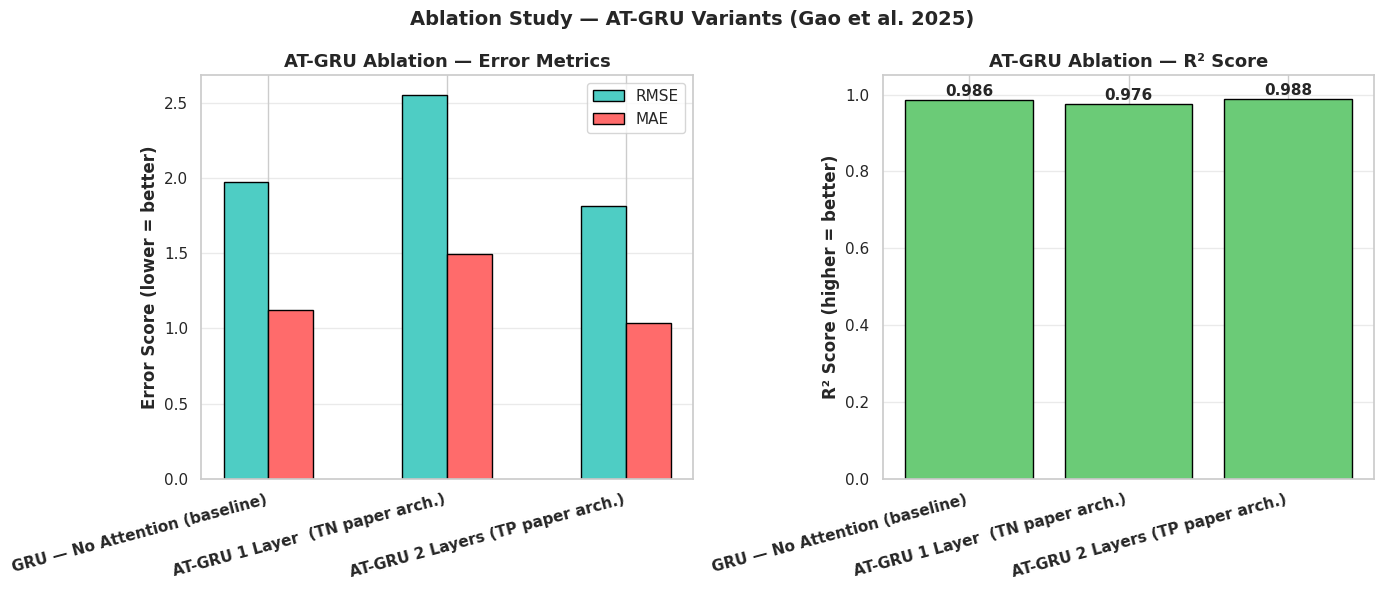


  ABLATION SUMMARY
                                    Variant     RMSE      MAE       R2
   Variant A: GRU — No Attention (baseline) 1.975193 1.123626 0.985583
Variant B: AT-GRU 1 Layer  (TN paper arch.) 2.556129 1.494230 0.975856
Variant C: AT-GRU 2 Layers (TP paper arch.) 1.816409 1.033858 0.987808


In [28]:
# ─────────────────────────────────────────────
# SECTION 19: Ablation Study — AT-GRU Variants
#
# Ablation tests architectural choices from the paper:
#   • Variant A : AT-GRU without Attention  (plain GRU only)
#   • Variant B : AT-GRU 1 layer  (TN architecture — 1×GRU)
#   • Variant C : AT-GRU 2 layers (TP architecture — 2×GRU)
#
# This replaces the original Dual-Branch ablation with GRU-based ablation
# matching the paper's Table A3 configurations.
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("ABLATION STUDY — AT-GRU Variants (Gao et al. 2025)")
print("="*80)


class GRU_NoAttention(nn.Module):
    """
    Ablation Variant A: Plain GRU without Attention.
    Uses the last hidden state instead of attention-weighted context.
    Baseline to measure the contribution of the Attention mechanism.
    """
    def __init__(self, input_dim, hidden_dim=100, dropout=0.2, output_dim=1):
        super().__init__()
        self.gru     = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h_all, _ = self.gru(x)
        h_all    = torch.relu(h_all)
        h_last   = h_all[:, -1, :]         # last time step (no attention)
        h_last   = self.dropout(h_last)
        return self.output(h_last)


def quick_train_eval(model_v, name, epochs=4):
    """Quick training + evaluation for ablation comparison."""
    opt  = optim.AdamW(model_v.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.MSELoss()

    model_v.train()
    for ep in range(epochs):
        for bx, by in train_loader:
            bx = bx.to(device); by = by.to(device)
            loss = crit(model_v(bx), by)
            opt.zero_grad(); loss.backward(); opt.step()

    model_v.eval()
    preds_all, targs_all = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds_all.extend(model_v(bx).cpu().numpy().flatten())
            targs_all.extend(by.cpu().numpy().flatten())

    rmse = np.sqrt(mean_squared_error(targs_all, preds_all))
    mae  = mean_absolute_error(targs_all, preds_all)
    r2   = r2_score(targs_all, preds_all)
    print(f"  [{name:<35}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2


# ── Run ablation configurations ───────────────────────────────────────────────
configs = [
    # (name, model_class, kwargs)
    ("Variant A: GRU — No Attention (baseline)",
     GRU_NoAttention,
     dict(input_dim=input_size, hidden_dim=100, dropout=0.2)),

    ("Variant B: AT-GRU 1 Layer  (TN paper arch.)",
     ATGRU,
     dict(input_dim=input_size, hidden_dim=100, n_gru_layers=1, dropout=0.2)),

    ("Variant C: AT-GRU 2 Layers (TP paper arch.)",
     ATGRU,
     dict(input_dim=input_size, hidden_dim=50,  n_gru_layers=2, dropout=0.2)),
]

ablation_results = {}
for name, ModelClass, kwargs in configs:
    m_abl = ModelClass(**kwargs).to(device)
    rmse, mae, r2 = quick_train_eval(m_abl, name, epochs=4)
    ablation_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    del m_abl; torch.cuda.empty_cache() if device.type == 'cuda' else None

# ── Visualise ablation results ────────────────────────────────────────────────
labels    = [k.split(":")[1].strip() for k in ablation_results.keys()]
rmse_vals = [ablation_results[k]['RMSE'] for k in ablation_results]
mae_vals  = [ablation_results[k]['MAE']  for k in ablation_results]
r2_vals   = [ablation_results[k]['R2']   for k in ablation_results]

x = np.arange(len(labels)); w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Error metrics
axes[0].bar(x - w/2, rmse_vals, w, label='RMSE', color='#4ECDC4', edgecolor='black')
axes[0].bar(x + w/2, mae_vals,  w, label='MAE',  color='#FF6B6B', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=11, fontweight='bold', rotation=15, ha='right')
axes[0].set_ylabel('Error Score (lower = better)', fontsize=12, fontweight='bold')
axes[0].set_title('AT-GRU Ablation — Error Metrics', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(axis='y', alpha=0.4)

# R2
axes[1].bar(x, r2_vals, color='#6BCB77', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=11, fontweight='bold', rotation=15, ha='right')
axes[1].set_ylabel('R² Score (higher = better)', fontsize=12, fontweight='bold')
axes[1].set_title('AT-GRU Ablation — R² Score', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].grid(axis='y', alpha=0.4)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Ablation Study — AT-GRU Variants (Gao et al. 2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
abl_df = pd.DataFrame([
    {'Variant': k, 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R2': v['R2']}
    for k, v in ablation_results.items()
])
print("\n" + "="*70)
print("  ABLATION SUMMARY")
print("="*70)
print(abl_df.to_string(index=False))
print("="*70)


In [29]:

# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)




 FINAL MODEL PERFORMANCE SUMMARY – Dual-Branch Regression
  Test MSE:     1.6521
  Test RMSE:    1.2853
  Test MAE:     0.6228
  R2 Score:     0.9939


In [30]:
# End of notebook — AT-GRU (Attention-GRU) Regression on CCME_Values
# Model: Gao et al., Environmental Pollution 383 (2025) 126801